This dataset represents an image classification problem because each image belongs to one specific category. The goal of the model is to classify an image into one of four classes:

- dent
- normal
- scratch
- stain

Image classification is appropriate because the dataset contains labelled images where each image is assigned a single class label. The model learns patterns and visual features from the images to predict the correct category.

Classes: ['dent', 'normal', 'scratch', 'stain']
dent: 120 images
normal: 120 images
scratch: 120 images
stain: 120 images


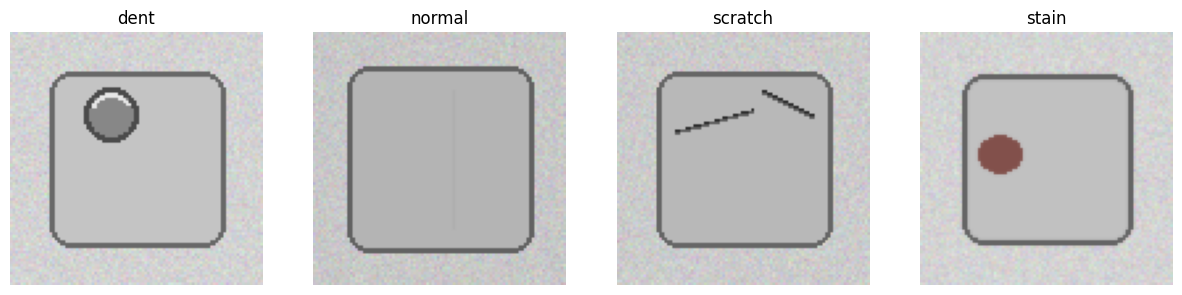

Image size: (96, 96)


In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "images"

# Only keep actual folders
classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Classes:", classes)

# Count images per class
for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    print(f"{cls}: {len(images)} images")

# Display sample images
fig, axes = plt.subplots(1, len(classes), figsize=(15,5))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    image_files = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    img_path = os.path.join(class_path, image_files[0])

    img = Image.open(img_path)

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

# Image dimensions
sample_img = Image.open(img_path)
print("Image size:", sample_img.size)

In [10]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Input(shape=(128, 128, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.2292 - loss: 1.5184 - val_accuracy: 0.2500 - val_loss: 1.3836
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.2734 - loss: 1.3877 - val_accuracy: 0.2500 - val_loss: 1.3825
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.2630 - loss: 1.3774 - val_accuracy: 0.2812 - val_loss: 1.3686
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.3542 - loss: 1.3493 - val_accuracy: 0.3854 - val_loss: 1.2922
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.4453 - loss: 1.1998 - val_accuracy: 0.6042 - val_loss: 1.1536
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.5599 - loss: 1.0212 - val_accuracy: 0.6354 - val_loss: 0.8615
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.6172 - loss: 0.8032 - val_accuracy: 0.8542 - val_loss: 0.5911
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.7448 - loss: 0.6476 - val_accuracy: 0.

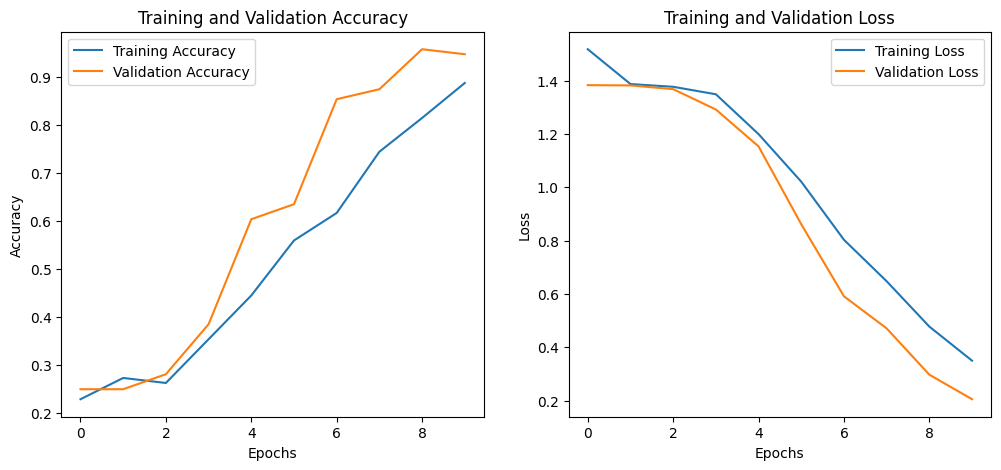

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("results/accuracy_loss_curves.png", bbox_inches="tight")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


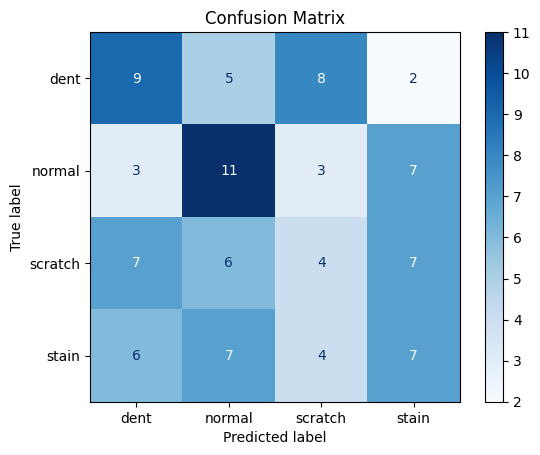

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

val_data.reset()

predictions = model.predict(val_data)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = val_data.classes
class_names = list(val_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png", bbox_inches="tight")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


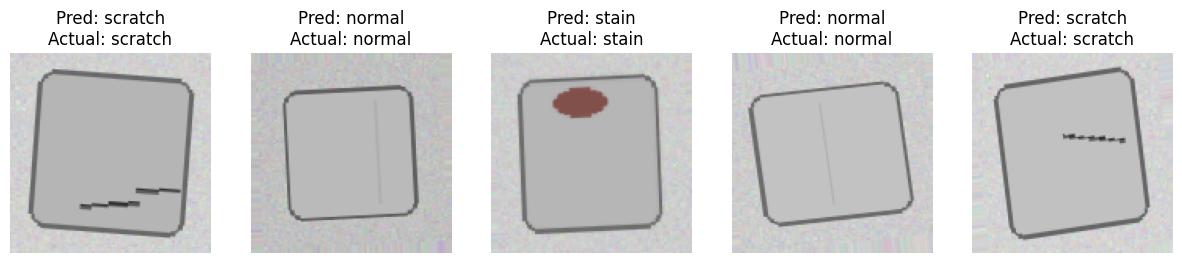

In [15]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = next(val_data)

predictions = model.predict(images)

class_names = list(val_data.class_indices.keys())

plt.figure(figsize=(15, 8))

for i in range(5):

    plt.subplot(1, 5, i + 1)

    plt.imshow(images[i])

    predicted_label = class_names[np.argmax(predictions[i])]

    actual_label = class_names[np.argmax(labels[i])]

    plt.title(f"Pred: {predicted_label}\nActual: {actual_label}")

    plt.axis("off")

plt.savefig("sample_predictions/prediction_outputs.png", bbox_inches="tight")

plt.show()

The training set was used for training the CNN model and validation set was used to validate the CNN model for 10 epochs.

Training and validation accuracy/loss curves were created to assess accuracy/loss of validation models over time.

A confusion matrix was created to study the accuracy of the model in the classification of each image category. The model was good in all four classes.

Predictions were also shown using the validation images. For the displayed examples, the CNN correctly predicted the associated labels, demonstrating that the CNN learned visual features associated with dents, scratches, stains, and normal surfaces.

The classification performance of the model was overall good, and it could successfully classify most defect categories.

# Business Use Case Mapping

This type of computer vision solution can be used in manufacturing for automated defect detection and quality inspection.

CNN can automatically recognize defects like dents, scratches, stains, etc. in manufactured products. This enables companies to enhance product quality, minimize manual inspection workload, cut production cost and detect product defects faster, and more accurately.